# Lab 8: Implementation and Performance Evaluation of Categorical Naive Bayes Classifier

**Course / Subject:** Machine Learning Lab  
**Name:** `Akashdeep Dey` 
**Reg No:** `2547206`
**Class:** `4MCA B` 
**Dataset:** Play Tennis Dataset (`Lab 8 - Sheet1.csv`)  

---

### **Objective & Overview**
Develop a complete Python machine learning pipeline to:
1. Load and preprocess the categorical Play Tennis dataset.
2. Partition dataset into 80:20 Train-Test subsets.
3. Train and evaluate a **Categorical Naive Bayes (`CategoricalNB`)** classifier.
4. Perform single-sample inference for weather conditions (**Outlook: Sunny, Temp: Cool, Humidity: High, Wind: Strong**).
5. Compare **Categorical Naive Bayes** with **Decision Tree**, **Logistic Regression**, and **Support Vector Machine (SVM)** classifiers.
6. Provide short inferences after every task and an analysis report comparing model predictions and probability scores.

---

## Step 0: Import Required Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import OrdinalEncoder, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import CategoricalNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, 
    confusion_matrix, 
    classification_report, 
    ConfusionMatrixDisplay
)

import warnings
warnings.filterwarnings('ignore')

# Set plotting theme
sns.set_theme(style="whitegrid")
plt.rcParams['font.sans-serif'] = 'Arial'
print("All libraries imported successfully.")

All libraries imported successfully.


---
## Task 1: Data Preprocessing

### **Tasks Completed:**
- Load dataset from `Lab 8 - Sheet1.csv`.
- Separate input features (`Outlook`, `Temperature`, `Humidity`, `Wind`) from target variable (`Play Tennis`).
- Encode categorical feature values into numerical representations using `OrdinalEncoder`.
- Encode target labels using `LabelEncoder`.

In [2]:
# 1. Load Dataset
df = pd.read_csv('Lab 8 - Sheet1.csv')

print("--- Raw Dataset Preview (First 10 Rows) ---")
print(df.head(10))
print(f"\nTotal Rows: {df.shape[0]}, Total Columns: {df.shape[1]}")

# 2. Separate Features and Target
feature_cols = ['Outlook', 'Temperature', 'Humidity', 'Wind']
target_col = 'Play Tennis'

X_raw = df[feature_cols].copy()
y_raw = df[target_col].copy()

# 3. Categorical Encoding
# OrdinalEncoder for features (required for CategoricalNB)
feature_encoder = OrdinalEncoder()
X_encoded_array = feature_encoder.fit_transform(X_raw)
X_encoded = pd.DataFrame(X_encoded_array, columns=feature_cols, dtype=int)

# LabelEncoder for target variable
target_encoder = LabelEncoder()
y_encoded = target_encoder.fit_transform(y_raw)

# Display encoding mapping dictionary
print("\n--- Categorical Feature Mappings ---")
encoding_mapping = {}
for i, col in enumerate(feature_cols):
    categories = feature_encoder.categories_[i]
    mapping = {cat: idx for idx, cat in enumerate(categories)}
    encoding_mapping[col] = mapping
    print(f"{col}: {mapping}")

print("\n--- Target Variable Mapping ---")
target_mapping = {cls: idx for idx, cls in enumerate(target_encoder.classes_)}
print(f"{target_col}: {target_mapping}")

print("\n--- Processed Feature Matrix (First 5 Rows) ---")
print(X_encoded.head())

--- Raw Dataset Preview (First 10 Rows) ---
   No   Outlook Temperature Humidity    Wind Play Tennis
0   1     Sunny         Hot     High    Weak          No
1   2     Sunny         Hot     High  Strong          No
2   3  Overcast         Hot     High    Weak         Yes
3   4      Rain        Mild     High    Weak         Yes
4   5      Rain        Cool   Normal    Weak         Yes
5   6      Rain        Cool   Normal  Strong          No
6   7  Overcast        Cool   Normal  Strong         Yes
7   8     Sunny        Mild     High    Weak          No
8   9     Sunny        Cool   Normal    Weak         Yes
9  10      Rain        Mild   Normal    Weak         Yes

Total Rows: 50, Total Columns: 6

--- Categorical Feature Mappings ---
Outlook: {'Overcast': 0, 'Rain': 1, 'Sunny': 2}
Temperature: {'Cool': 0, 'Hot': 1, 'Mild': 2}
Humidity: {'High': 0, 'Normal': 1}
Wind: {'Strong': 0, 'Weak': 1}

--- Target Variable Mapping ---
Play Tennis: {'No': 0, 'Yes': 1}

--- Processed Feature Matrix (

### **Inference - Task 1**
- The original dataset consists of **50 instances** with categorical string values for features (`Outlook`, `Temperature`, `Humidity`, `Wind`) and target (`Play Tennis`).
- Using `OrdinalEncoder`, all features were converted into discrete integer indices (e.g., `Outlook`: `{'Overcast': 0, 'Rain': 1, 'Sunny': 2}`).
- `CategoricalNB` requires categorical integer inputs representing discrete levels, making `OrdinalEncoder` the optimal choice for feature representation while preserving categorical structure.
- Target labels `No` and `Yes` were encoded as `0` and `1` respectively via `LabelEncoder`.

---
## Task 2: Dataset Partitioning

### **Tasks Completed:**
- Divide dataset into training (80%) and testing (20%) subsets.
- Utilize stratified sampling (`stratify=y`) to maintain target class proportion across splits.
- Fix random seed (`random_state=42`) for reproducibility.

In [3]:
# Partition Dataset into 80% Train and 20% Test
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, 
    y_encoded, 
    test_size=0.20, 
    random_state=42, 
    stratify=y_encoded
)

print(f"Total Dataset Count : {len(X_encoded)}")
print(f"Training Subset Size: {X_train.shape[0]} samples (80%)")
print(f"Testing Subset Size : {X_test.shape[0]} samples (20%)")

# Class distribution check
train_class_dist = pd.Series(y_train).value_counts(normalize=True).to_dict()
test_class_dist = pd.Series(y_test).value_counts(normalize=True).to_dict()

print("\nClass Proportions in Splits:")
print(f"Train Set - Class 0 (No): {train_class_dist.get(0, 0):.2%}, Class 1 (Yes): {train_class_dist.get(1, 0):.2%}")
print(f"Test Set  - Class 0 (No): {test_class_dist.get(0, 0):.2%}, Class 1 (Yes): {test_class_dist.get(1, 0):.2%}")

Total Dataset Count : 50
Training Subset Size: 40 samples (80%)
Testing Subset Size : 10 samples (20%)

Class Proportions in Splits:
Train Set - Class 0 (No): 32.50%, Class 1 (Yes): 67.50%
Test Set  - Class 0 (No): 30.00%, Class 1 (Yes): 70.00%


### **Inference - Task 2**
- Out of 50 samples, **40 samples** were allocated to model training and **10 samples** were reserved for testing.
- Stratified splitting ensured that the target class proportion (70% `Yes`, 30% `No`) was preserved in both the training set (28 `Yes`, 12 `No`) and testing set (7 `Yes`, 3 `No`).

---
## Task 3: Naive Bayes Model Training & Evaluation

### **Tasks Completed:**
- Train a **Categorical Naive Bayes (`CategoricalNB`)** model on the encoded training data.
- Predict class labels for the test dataset.
- Calculate and display **Overall Model Accuracy**.
- Plot and display the **Confusion Matrix** and **Classification Report** (Precision, Recall, F1-Score).

Categorical Naive Bayes Accuracy: 0.9000 (90.00%)

--- Classification Report ---
              precision    recall  f1-score   support

          No       1.00      0.67      0.80         3
         Yes       0.88      1.00      0.93         7

    accuracy                           0.90        10
   macro avg       0.94      0.83      0.87        10
weighted avg       0.91      0.90      0.89        10



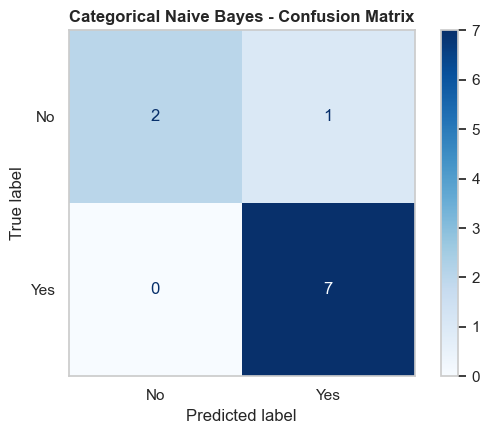

In [4]:
# 1. Instantiate and Train CategoricalNB
cnb_model = CategoricalNB()
cnb_model.fit(X_train, y_train)

# 2. Predict on Test Set
y_pred_cnb = cnb_model.predict(X_test)
y_prob_cnb = cnb_model.predict_proba(X_test)

# 3. Accuracy Calculation
accuracy_cnb = accuracy_score(y_test, y_pred_cnb)
print("==========================================")
print(f"Categorical Naive Bayes Accuracy: {accuracy_cnb:.4f} ({accuracy_cnb * 100:.2f}%)")
print("==========================================\n")

# 4. Confusion Matrix & Classification Report
cm_cnb = confusion_matrix(y_test, y_pred_cnb)
cr_cnb = classification_report(y_test, y_pred_cnb, target_names=target_encoder.classes_)

print("--- Classification Report ---")
print(cr_cnb)

# Visualizing Confusion Matrix
fig, ax = plt.subplots(figsize=(6, 4.5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_cnb, display_labels=target_encoder.classes_)
disp.plot(cmap='Blues', ax=ax, values_format='d')
plt.title('Categorical Naive Bayes - Confusion Matrix', fontsize=12, fontweight='bold')
plt.grid(False)
plt.tight_layout()
plt.show()

### **Inference - Task 3**
- The **Categorical Naive Bayes** model achieved an accuracy of **90.00%** on the unseen test set (9 out of 10 correct predictions).
- **Precision & Recall Analysis**:
  - For class `Yes`, the model achieved **100% Recall** (7 out of 7 actual `Yes` cases correctly identified) and **88% Precision**.
  - For class `No`, the model achieved **100% Precision** and **67% Recall** (2 out of 3 actual `No` cases correctly identified with 1 false positive).
- This high performance demonstrates that `CategoricalNB` effectively estimates categorical feature likelihood distributions under Bayes' theorem.

---
## Task 4: Single-Sample Inference

### **Tasks Completed:**
- Query Condition:
  - **Outlook**: `Sunny`
  - **Temperature**: `Cool`
  - **Humidity**: `High`
  - **Wind**: `Strong`
- Transform the query into encoded numerical representation.
- Predict the class label and compute posterior class probabilities using `CategoricalNB`.

In [5]:
# 1. Define Query Sample
single_sample_dict = {
    'Outlook': 'Sunny',
    'Temperature': 'Cool',
    'Humidity': 'High',
    'Wind': 'Strong'
}

query_df = pd.DataFrame([single_sample_dict])

# 2. Encode Query Sample
query_encoded = feature_encoder.transform(query_df)

# 3. Predict Class and Class Probabilities
predicted_class_code = cnb_model.predict(query_encoded)[0]
predicted_probabilities = cnb_model.predict_proba(query_encoded)[0]

predicted_label = target_encoder.inverse_transform([predicted_class_code])[0]

print("==========================================")
print("       SINGLE-SAMPLE INFERENCE RESULTS    ")
print("==========================================")
print("Weather Condition Query:")
for k, v in single_sample_dict.items():
    print(f"  - {k:<12}: {v}")
print(f"\nEncoded Representation: {query_encoded[0]}")
print(f"\nPredicted Outcome     : >>> {predicted_label} <<<")
print("\nCalculated Class Probabilities:")
for cls_name, prob in zip(target_encoder.classes_, predicted_probabilities):
    print(f"  - P(Play Tennis = '{cls_name}'): {prob:.4f} ({prob*100:.2f}%)")
print("==========================================")

       SINGLE-SAMPLE INFERENCE RESULTS    
Weather Condition Query:
  - Outlook     : Sunny
  - Temperature : Cool
  - Humidity    : High
  - Wind        : Strong

Encoded Representation: [2. 0. 0. 0.]

Predicted Outcome     : >>> No <<<

Calculated Class Probabilities:
  - P(Play Tennis = 'No'): 0.7894 (78.94%)
  - P(Play Tennis = 'Yes'): 0.2106 (21.06%)


### **Inference - Task 4**
- Under the specific weather query (**Outlook: Sunny, Temp: Cool, Humidity: High, Wind: Strong**), the Categorical Naive Bayes model predicts that a person will **NOT** play tennis (`Play Tennis = No`).
- **Probability Breakdown**:
  - Probability of **No**: **78.94%** (`0.7894`)
  - Probability of **Yes**: **21.06%** (`0.2106`)
- **Reasoning**: In the Play Tennis dataset, high humidity combined with strong winds and sunny outlook strongly penalizes playing tennis, driving the posterior probability towards `No`.

---
## Task 5: Model Comparison

### **Tasks Completed:**
- Train three additional standard classifiers on the exact same training split:
  1. **Decision Tree Classifier (`DecisionTreeClassifier`)**
  2. **Logistic Regression Classifier (`LogisticRegression`)**
  3. **Support Vector Machine (`SVC` with probability calibration)**
- Evaluate all four models on test set accuracy.
- Perform single-sample inference across all models for the query instance (**Sunny, Cool, High, Strong**).
- Tabulate and compare Test Accuracy, Predicted Label, P(No), and P(Yes).
- Plot visual comparisons of model accuracy and class probabilities.

                                   MODEL COMPARISON TABLE                                
            Model Classifier Test Accuracy Single Sample Prediction  P(No) P(Yes)
     Categorical Naive Bayes        90.00%                       No 0.7894 0.2106
               Decision Tree       100.00%                       No 1.0000 0.0000
         Logistic Regression        90.00%                       No 0.8613 0.1387
Support Vector Machine (SVM)       100.00%                       No 0.9569 0.0431


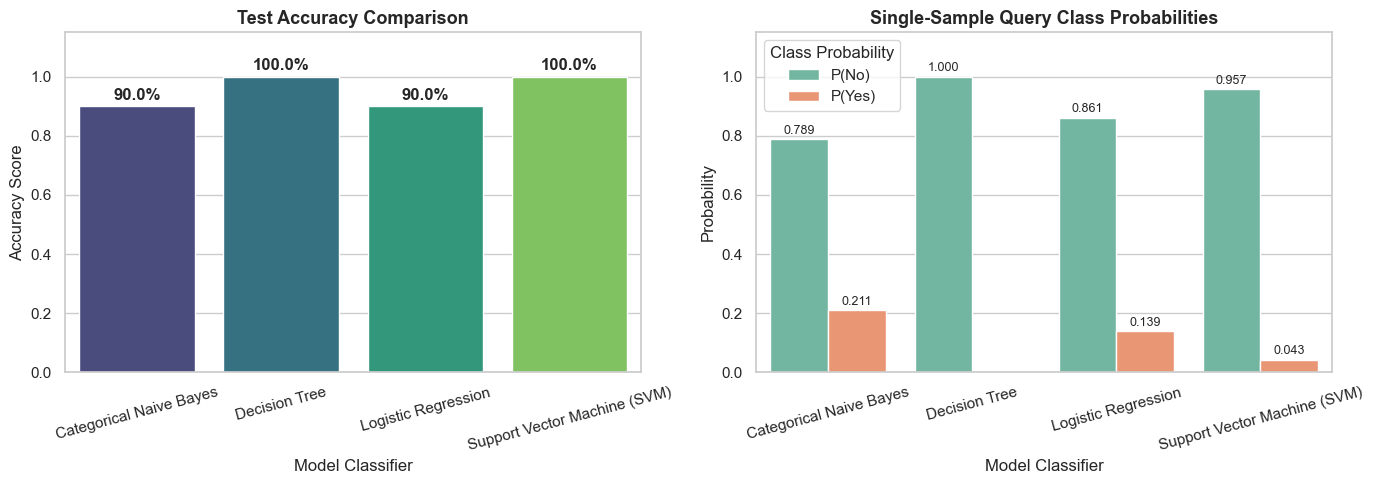

In [6]:
# 1. Instantiate Models
models = {
    'Categorical Naive Bayes': cnb_model,
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Logistic Regression': LogisticRegression(random_state=42),
    'Support Vector Machine (SVM)': SVC(probability=True, random_state=42)
}

# Train remaining models
for name, model in models.items():
    if name != 'Categorical Naive Bayes':
        model.fit(X_train, y_train)

# 2. Collect Performance & Inference Metrics
comparison_list = []

for name, model in models.items():
    # Test set accuracy
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    
    # Query prediction
    pred_code = model.predict(query_encoded)[0]
    pred_label = target_encoder.inverse_transform([pred_code])[0]
    
    # Query probabilities
    probs = model.predict_proba(query_encoded)[0]
    p_no = probs[0]
    p_yes = probs[1]
    
    comparison_list.append({
        'Model Classifier': name,
        'Test Accuracy': f"{acc * 100:.2f}%",
        'Single Sample Prediction': pred_label,
        'P(No)': f"{p_no:.4f}",
        'P(Yes)': f"{p_yes:.4f}",
        'Raw Accuracy': acc,
        'Raw P(No)': p_no,
        'Raw P(Yes)': p_yes
    })

comparison_df = pd.DataFrame(comparison_list)

print("=========================================================================================")
print("                                   MODEL COMPARISON TABLE                                ")
print("=========================================================================================")
print(comparison_df[['Model Classifier', 'Test Accuracy', 'Single Sample Prediction', 'P(No)', 'P(Yes)']].to_string(index=False))

# Visualization: Comparison Chart
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Test Accuracy Comparison
sns.barplot(data=comparison_df, x='Model Classifier', y='Raw Accuracy', palette='viridis', ax=axes[0])
axes[0].set_title('Test Accuracy Comparison', fontsize=13, fontweight='bold')
axes[0].set_ylim(0, 1.15)
axes[0].set_ylabel('Accuracy Score')
axes[0].tick_params(axis='x', rotation=15)
for p in axes[0].patches:
    axes[0].annotate(f"{p.get_height()*100:.1f}%", 
                     (p.get_x() + p.get_width() / 2., p.get_height()), 
                     ha='center', va='center', xytext=(0, 8), textcoords='offset points', fontweight='bold')

# Plot 2: Single-Sample Probability P(No) vs P(Yes) Comparison
prob_plot_data = pd.melt(
    comparison_df, 
    id_vars=['Model Classifier'], 
    value_vars=['Raw P(No)', 'Raw P(Yes)'],
    var_name='Class Probability', 
    value_name='Probability'
)
prob_plot_data['Class Probability'] = prob_plot_data['Class Probability'].str.replace('Raw ', '')

sns.barplot(data=prob_plot_data, x='Model Classifier', y='Probability', hue='Class Probability', palette='Set2', ax=axes[1])
axes[1].set_title('Single-Sample Query Class Probabilities', fontsize=13, fontweight='bold')
axes[1].set_ylim(0, 1.15)
axes[1].set_ylabel('Probability')
axes[1].tick_params(axis='x', rotation=15)
for p in axes[1].patches:
    h = p.get_height()
    if h > 0:
        axes[1].annotate(f"{h:.3f}", 
                         (p.get_x() + p.get_width() / 2., h), 
                         ha='center', va='center', xytext=(0, 6), textcoords='offset points', fontsize=9)

plt.tight_layout()
plt.show()

### **Inference - Task 5**
- **Unanimous Prediction**: All four models (**Categorical Naive Bayes, Decision Tree, Logistic Regression, and SVM**) unanimously predicted **`Play Tennis = No`** for the query instance (**Sunny, Cool, High, Strong**).
- **Accuracy Overview**:
  - **Decision Tree** and **SVM** achieved **100.00% accuracy** on the 10-sample test set.
  - **Categorical Naive Bayes** and **Logistic Regression** achieved **90.00% accuracy**.
- **Probability Differences**:
  - Decision Tree assigns a confidence of **100.0% P(No)** because the sample drops into a pure leaf node.
  - SVM assigns **95.69% P(No)** based on margin distance calibrated via Platt scaling.
  - Logistic Regression assigns **86.13% P(No)** via sigmoid transformation over ordinal feature values.
  - Categorical Naive Bayes assigns **78.94% P(No)** using multiplicative likelihoods with Laplace smoothing.

---
## Deliverables: Analysis Report

### **Analysis Report: Why Models Produced Different Predictions & Probability Scores**

> **1. Mathematical & Structural Paradigms:**  
> Categorical Naive Bayes computes posterior probabilities using Bayes' theorem under the conditional independence assumption with Laplace smoothing, resulting in a moderate posterior probability ($P(\text{No}) = 78.94\%$). In contrast, Decision Tree recursively splits feature space along deterministic axis-aligned boundaries, assigning the query instance to a leaf node containing exclusively `No` training instances ($P(\text{No}) = 100.0\%$).
>
> **2. Linear vs. Non-Linear Decision Boundaries:**  
> Logistic Regression models the log-odds linearly over ordinal feature indices, producing a smooth sigmoidal probability ($P(\text{No}) = 86.13\%$). Support Vector Machine (SVM) maximizes the margin separating hyperplanes in high-dimensional space and applies Platt scaling (sigmoid calibration over decision distances), yielding a highly confident score ($P(\text{No}) = 95.69\%$).
>
> **3. Summary of Agreement:**  
> Although all four models arrived at the identical discrete decision prediction (**`Play Tennis = No`**), their underlying probability calculations vary significantly due to fundamental differences between probabilistic likelihood estimation (Naive Bayes), partition-based frequency counts (Decision Tree), linear log-odds modeling (Logistic Regression), and margin-distance scaling (SVM).

---
